In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
os.chdir('/Users/Hp/Ciencia de datos/Regresión lineal')

In [66]:
data = pd.read_csv('recursos_humanos.csv')
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [78]:
data.info()
data.isna().sum

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


<bound method DataFrame.sum of        satisfaction_level  last_evaluation  number_project  \
0                   False            False           False   
1                   False            False           False   
2                   False            False           False   
3                   False            False           False   
4                   False            False           False   
...                   ...              ...             ...   
14994               False            False           False   
14995               False            False           False   
14996               False            False           False   
14997               False            False           False   
14998               False            False           False   

       average_montly_hours  time_spend_company  Work_accident   left  \
0                     False               False          False  False   
1                     False               False          False  False   
2    

In [82]:
df2 = pd.get_dummies(data, columns=['sales','salary'], drop_first=True)
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [90]:
y = df2['left']
X = df2.drop(columns=['left'])

In [92]:
y.value_counts()
y.value_counts(normalize=True)

left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

In [94]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size= 0.30, random_state= 1, stratify= y)

In [96]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.fit_transform(X_test)

In [100]:
results = []
for k in range(1,2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    results.append([k, acc])

tabla_k = pd.DataFrame(results, columns=['k', 'accuracy'])
tabla_k

,k,accuracy
0,1,0.960889


In [104]:
best_k = tabla_k.loc[tabla_k['accuracy'].idxmax(),'k']
best_acc = tabla_k['accuracy'].max()
best_k, best_acc

(1, 0.9608888888888889)

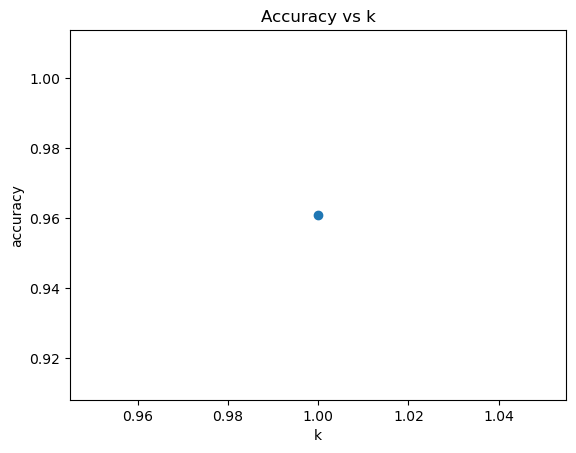

In [106]:
plt.plot(tabla_k['k'], tabla_k['accuracy'], marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('Accuracy vs k')
plt.show()

In [108]:
knn_opt = KNeighborsClassifier(n_neighbors= best_k)
knn_opt.fit(X_train_sc, y_train)

y_pred_opt = knn_opt.predict(X_test_sc)

In [110]:
cm = confusion_matrix(y_test, y_pred_opt)
cm

array([[3305,  124],
       [  52, 1019]], dtype=int64)

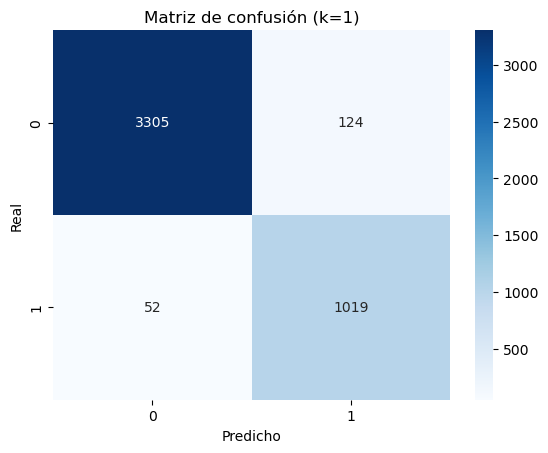

In [112]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title(f'Matriz de confusión (k={best_k})')
plt.show()

In [122]:
y_score = knn_opt.predict_proba(X_test_sc)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

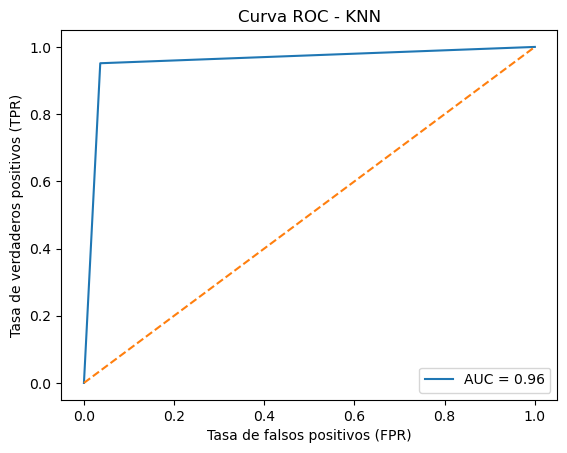

In [124]:
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - KNN')
plt.legend()
plt.show()

La curva ROC del modelo KNN muestra el desempeño del clasificador al variar el umbral de decisión, comparando la tasa de verdaderos positivos (TPR) contra la tasa de falsos positivos (FPR); como la curva queda muy por encima de la diagonal y se acerca a la esquina superior izquierda, el modelo